<a href="https://colab.research.google.com/github/DAclarissememba-png/DAclarissememba/blob/main/Python_coding2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup and Imports

This section handles the initial environment setup, including installing necessary libraries and importing them. It also connects to Google Drive.

In [1]:
# ==== SETUP: install and import libraries ====
# Run this cell once whenever you (re)connect to the runtime.

# 1. Install any libraries
!pip install pandas matplotlib seaborn --quiet

# 2. Import all the core libraries you’ll use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Global display options (optional)
pd.set_option("display.max_rows", 10)
sns.set(style="whitegrid")

print("Setup complete")

Setup complete


In [2]:
# Connect this notebook to your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. GDP Data Loading and Preprocessing

This section focuses on loading the GDP per Capita dataset, cleaning the 'Country/Territory' column, converting data types, and performing initial data inspection, including outlier detection for IMF estimates.

In [3]:
from google.colab import files
uploaded = files.upload()

# Assuming 'GDP (nominal) per Capita.csv' was uploaded. Adjust if the filename differs.
df_gdp = pd.read_csv('GDP (nominal) per Capita.csv')
print(f"Shape: {df_gdp.shape}")
display(df_gdp.head())

Saving GDP (nominal) per Capita.csv to GDP (nominal) per Capita.csv
Shape: (223, 9)


,Unnamed: 0,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
0,1,Monaco,Europe,0,0,234316,2021,234317,2021
1,2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
2,3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
3,4,Ireland,Europe,114581,2023,100172,2021,101109,2021
4,5,Bermuda,Americas,0,0,114090,2021,112653,2021


### 2.1 Data Cleaning and Type Conversion

In [4]:
# Strip whitespace from 'Country/Territory' column and ensure it's string type
df_gdp['Country/Territory'] = df_gdp['Country/Territory'].astype(str).str.strip()

# Convert 'WorldBank_Estimate' to integer, coercing errors and filling NaN with 0
df_gdp['WorldBank_Estimate'] = pd.to_numeric(df_gdp['WorldBank_Estimate'], errors='coerce').fillna(0).astype(int)

# Convert 'IMF_Year' to datetime, specifying format and coercing errors
df_gdp['IMF_Year'] = pd.to_datetime(df_gdp['IMF_Year'], format='%Y', errors='coerce')

print("Data types after cleaning:")
print(df_gdp.dtypes)

Data types after cleaning:
Unnamed: 0                     int64
Country/Territory             object
UN_Region                     object
IMF_Estimate                   int64
IMF_Year              datetime64[ns]
WorldBank_Estimate             int64
WorldBank_Year                 int64
UN_Estimate                    int64
UN_Year                       object
dtype: object


### 2.2 Outlier Detection for IMF Estimates

In [5]:
col = 'IMF_Estimate'

Q1 = df_gdp[col].quantile(0.25)
Q3 = df_gdp[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_gdp = df_gdp[(df_gdp[col] < lower) | (df_gdp[col] > upper)]

print("Outliers shape:", outliers_gdp.shape)
display(outliers_gdp.head())

Outliers shape: (23, 9)


,Unnamed: 0,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
2,3,Luxembourg,Europe,132372,2023-01-01,133590,2021,133745,2021
3,4,Ireland,Europe,114581,2023-01-01,100172,2021,101109,2021
5,6,Norway,Europe,101103,2023-01-01,89154,2021,89242,2021
6,7,Switzerland,Europe,98767,2023-01-01,91992,2021,93525,2021
7,8,Singapore,Asia,91100,2023-01-01,72794,2021,66822,2021


## 3. GDP Exploratory Data Analysis (EDA)

This section provides visualizations and correlation analysis for the GDP data to understand distributions and relationships between variables.

### 3.1 Correlation Analysis

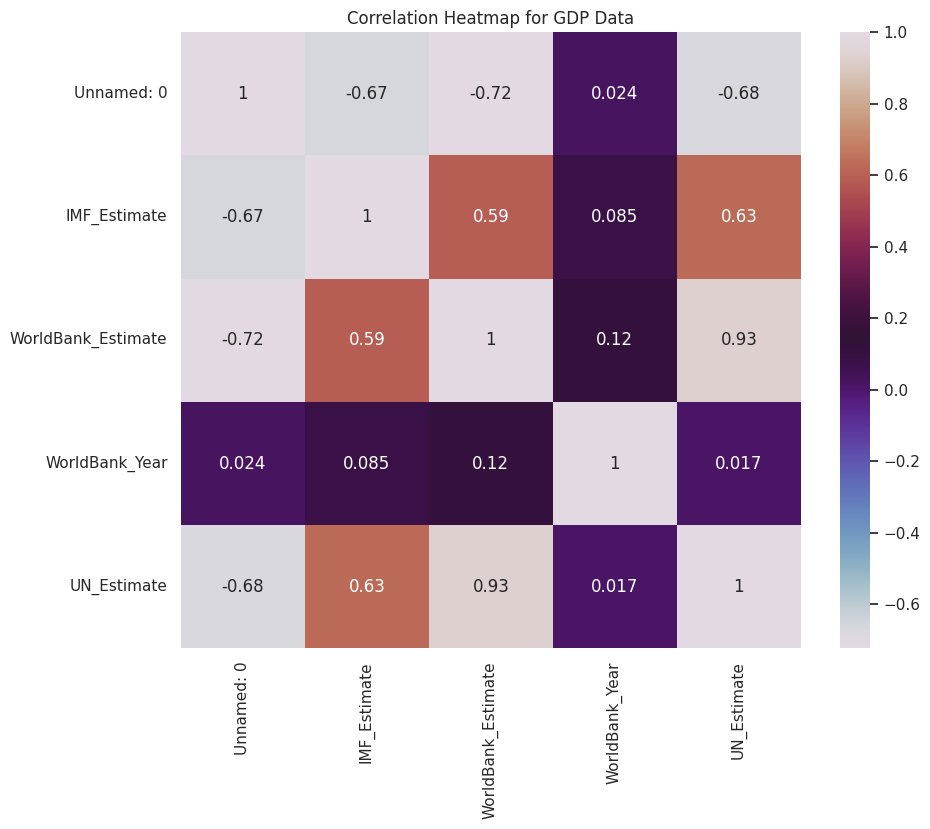

Available colormaps:
['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'tw

In [6]:
# Select only the numerical features for correlation analysis
numerical_features_gdp = df_gdp.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_gdp = numerical_features_gdp.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_gdp, annot=True, cmap='twilight')
plt.title('Correlation Heatmap for GDP Data')
plt.show()

print("Available colormaps:")
print(plt.colormaps())

### 3.2 Distribution Plots

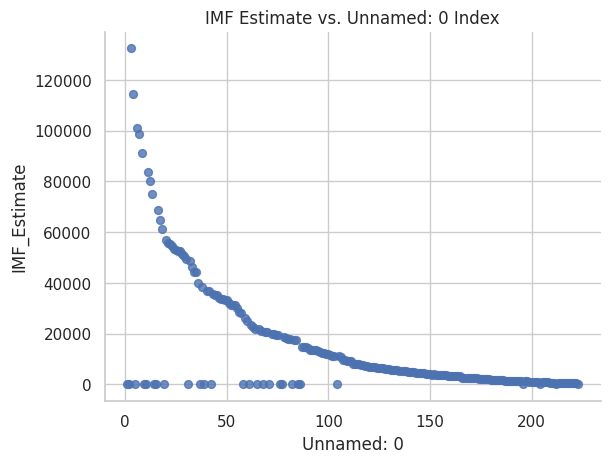

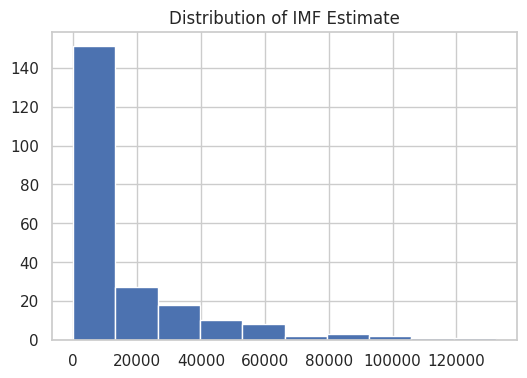

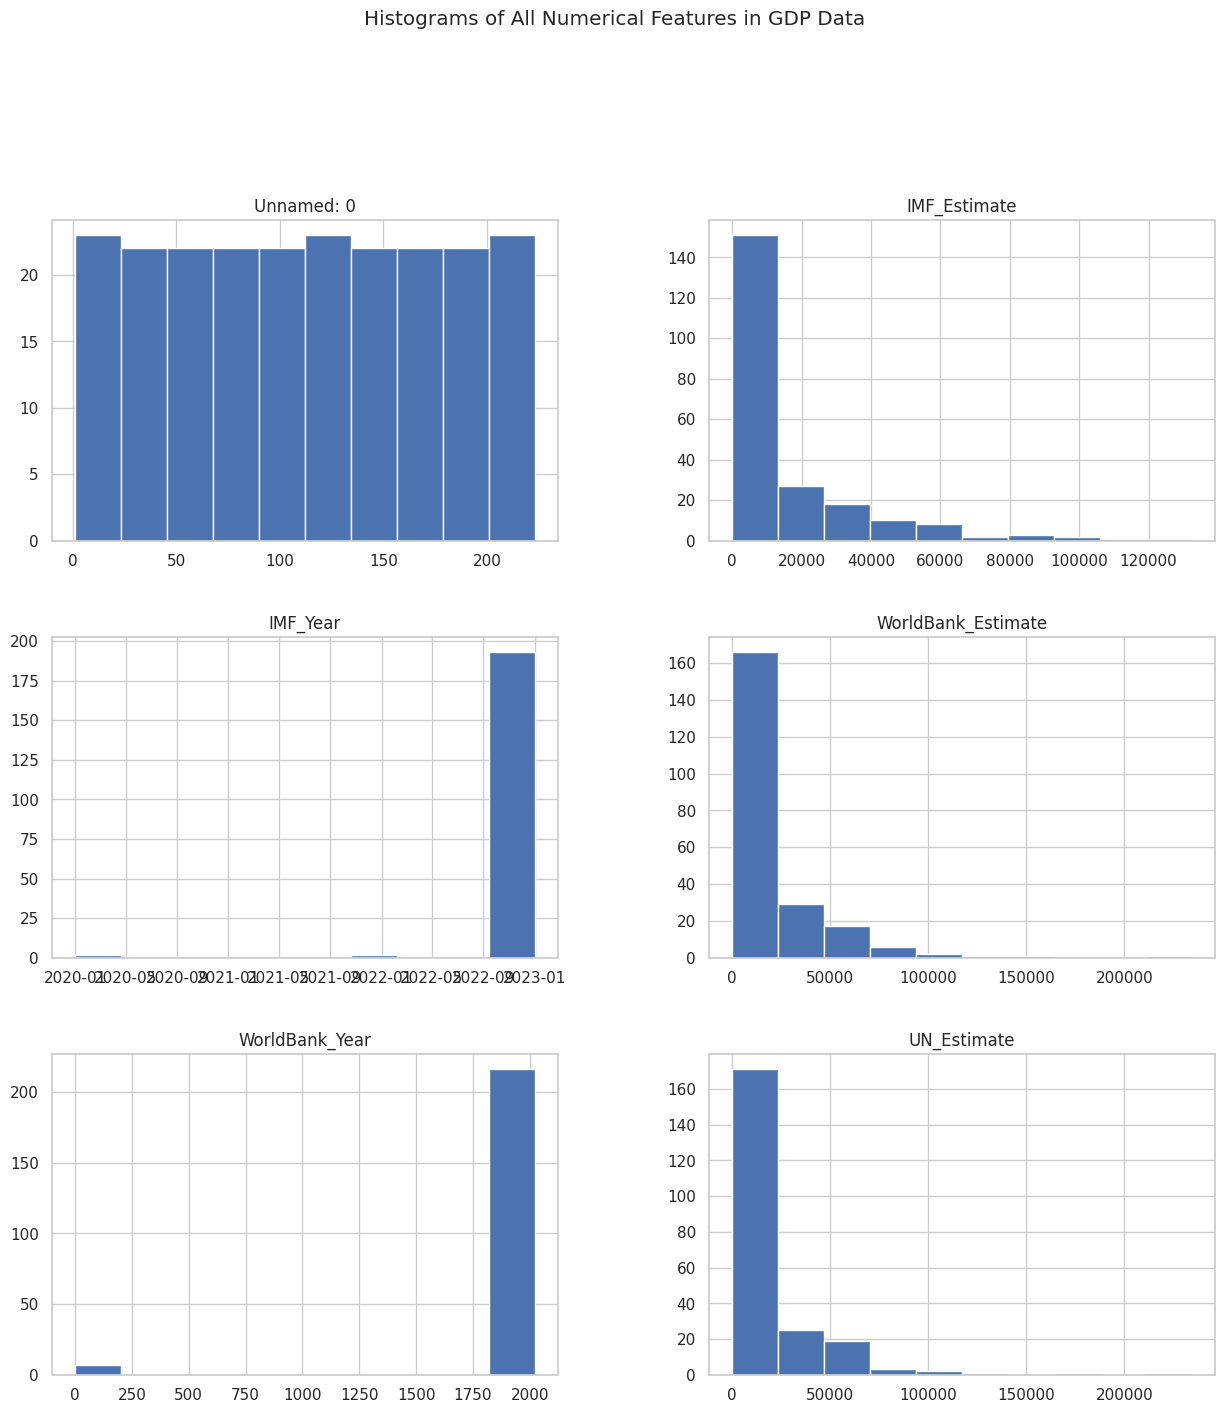

In [7]:
# Scatter plot: 'IMF_Estimate' vs 'Unnamed: 0'
df_gdp.plot(kind='scatter', x='Unnamed: 0', y='IMF_Estimate', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('IMF Estimate vs. Unnamed: 0 Index')
plt.show()

# Histogram for 'IMF_Estimate'
df_gdp.hist(column='IMF_Estimate', figsize=(6, 4))
plt.title('Distribution of IMF Estimate')
plt.show()

# Histograms for all numerical features
df_gdp.hist(figsize=(15, 15))
plt.suptitle('Histograms of All Numerical Features in GDP Data', y=1.02)
plt.show()

### 3.3 Regional Analysis

/tmp/ipykernel_594/2041659739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="UN_Region", y="IMF_Estimate", data=df_gdp, errorbar=None, palette="Set2")


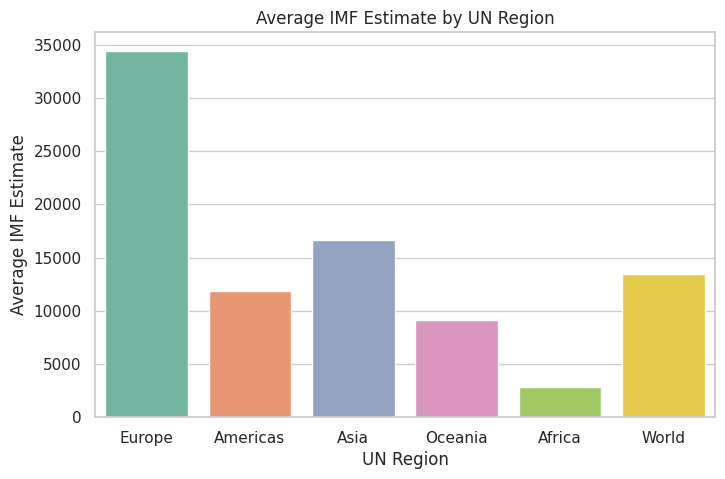

Example Seaborn color palettes:


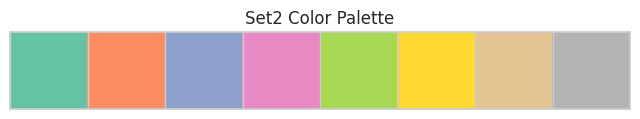

All available Seaborn palettes:
dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])


In [8]:
# Bar plot: Average IMF Estimate by UN Region
fig = plt.figure(figsize=(8, 5))
sns.barplot(x="UN_Region", y="IMF_Estimate", data=df_gdp, errorbar=None, palette="Set2")
plt.title('Average IMF Estimate by UN Region')
plt.xlabel('UN Region')
plt.ylabel('Average IMF Estimate')
plt.show()

print("Example Seaborn color palettes:")
sns.palplot(sns.color_palette("Set2"))
plt.title('Set2 Color Palette')
plt.show()
print("All available Seaborn palettes:")
print(sns.palettes.SEABORN_PALETTES.keys())

### 3.4 Relationship Between World Bank and UN Estimates

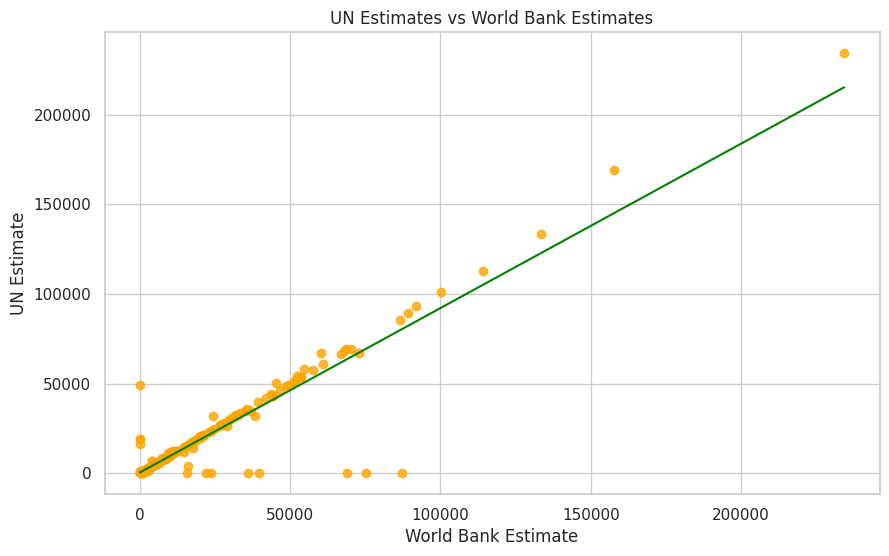

In [9]:
# Scatter plot: UN Estimates vs World Bank Estimates with trend line
plt.figure(figsize=(10, 6))
plt.scatter(df_gdp['WorldBank_Estimate'], df_gdp['UN_Estimate'], color='orange', alpha=0.8) # Changed initial blue to orange for consistency with trend line

plt.title('UN Estimates vs World Bank Estimates')
plt.xlabel('World Bank Estimate')
plt.ylabel('UN Estimate')

plt.grid(True)

# Calculate and plot the trend line
m, b = np.polyfit(df_gdp['WorldBank_Estimate'], df_gdp['UN_Estimate'], 1)  # Linear fit
plt.plot(df_gdp['WorldBank_Estimate'], m * df_gdp['WorldBank_Estimate'] + b, color='green', linestyle='-')

plt.show()

In [ ]:
print("Dataset loaded: Filename.csv")
print(f"Shape: {df.shape}")


Dataset loaded: Filename.csv
Shape: (223, 9)


In [ ]:
df['Country/Territory'] = df['Country/Territory'].str.strip()

In [ ]:
col = 'IMF_Estimate'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]


In [ ]:

# 3. Print outliers shape
print("Outliers shape:", outliers.shape)

Outliers shape: (23, 9)


In [ ]:
df['IMF_Year'] = pd.to_datetime(
    df['IMF_Year'],
    format='%Y',
    errors='coerce'
)

In [ ]:
print(df['IMF_Year'].head())

0          NaT
1          NaT
2   2023-01-01
3   2023-01-01
4          NaT
Name: IMF_Year, dtype: datetime64[ns]


In [ ]:
print(df['IMF_Year'].dtype)

datetime64[ns]


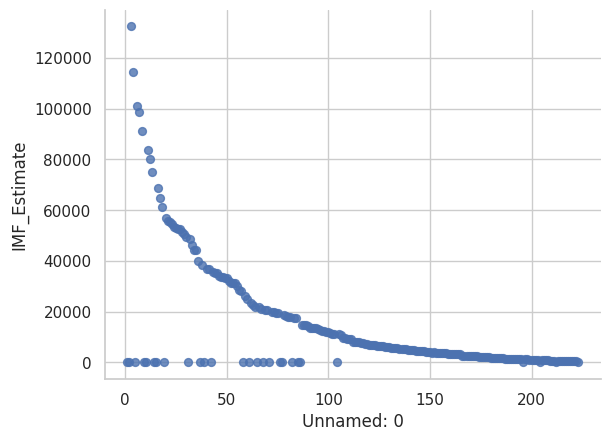

In [ ]:
df.plot(kind='scatter', x='Unnamed: 0', y='IMF_Estimate', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)


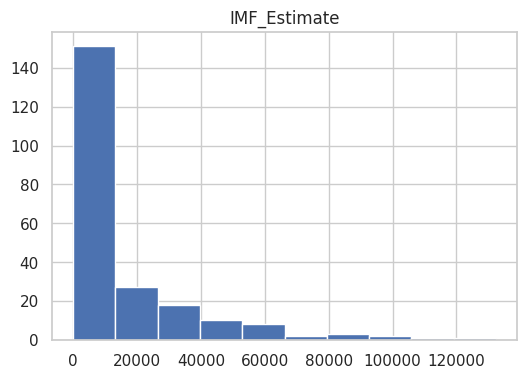

In [ ]:
df.hist(column='IMF_Estimate', figsize=(6, 4))
plt.show()


## 4. Student Data Loading and Preprocessing
This section covers loading the student performance dataset and displaying its initial structure.

In [ ]:
from google.colab import files
uploaded = files.upload()

#Then choose Student.csv file


Saving student.csv to student.csv


In [ ]:
# Use the exact filename you have just uploaded
df = pd.read_csv('student.csv')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df.head()

,id,name,class,mark,gender
0,1,John Deo,Four,75,female
1,2,Max Ruin,Three,85,male
2,3,Arnold,Three,55,male
3,4,Krish Star,Four,60,female
4,5,John Mike,Four,60,female


### 4.1 Marks Distribution by Class

/tmp/ipykernel_8054/752802950.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='mark', data=df, palette='Set2')


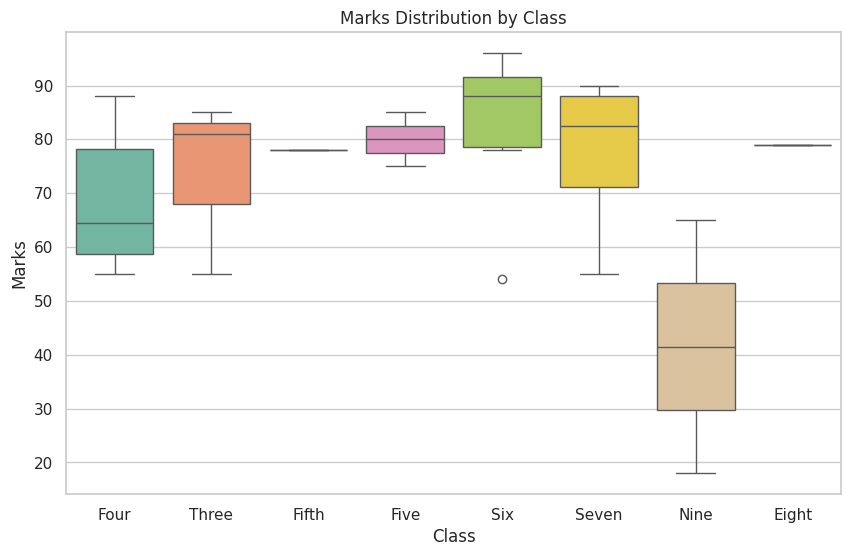

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='mark', data=df, palette='Set2')
plt.title('Marks Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Marks')
plt.show()


 4.2 Average marks distribution by gendre

/tmp/ipykernel_8054/2543529193.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='mark', data=avg_marks_gender, palette='pastel')  # Change 'deep' to your preferred palette


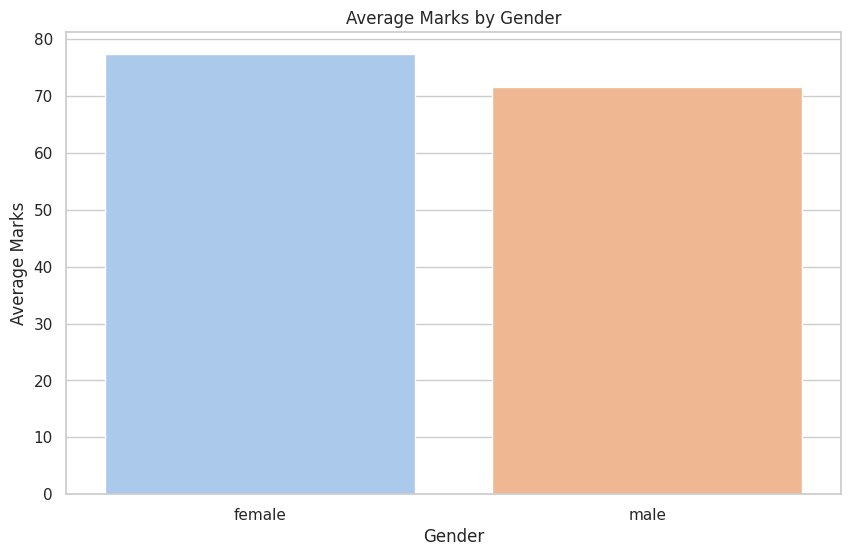

In [ ]:
plt.figure(figsize=(10, 6))
avg_marks_gender = df.groupby('gender')['mark'].mean().reset_index()
sns.barplot(x='gender', y='mark', data=avg_marks_gender, palette='pastel')  # Change 'deep' to your preferred palette
plt.title('Average Marks by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Marks')
plt.show()


In [ ]:
# See the built in Seaborn palette names
print(sns.palettes.SEABORN_PALETTES.keys())


dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])
